In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_data.csv")

df.head()

,Date,Store_ID,Product_Category,Price,Discount,Advertising_Spend,Holiday,Temperature,Competitor_Price,Units_Sold
0,2022-01-01,S09,Electronics,321.52,0,3733.60,0,16.9,298.34,50
1,2022-01-02,S01,Sports,297.29,0,246.01,0,16.1,297.61,31
2,2022-01-03,S03,Furniture,103.42,25,3536.49,0,21.7,102.37,15
3,2022-01-04,S07,Electronics,173.42,5,1155.04,0,31.4,159.62,35
4,2022-01-05,S07,Electronics,182.69,10,3058.26,0,32.6,191.08,17


In [3]:
df.shape

(15000, 10)

In [4]:
df.columns

Index(['Date', 'Store_ID', 'Product_Category', 'Price', 'Discount',
       'Advertising_Spend', 'Holiday', 'Temperature', 'Competitor_Price',
       'Units_Sold'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               15000 non-null  object 
 1   Store_ID           15000 non-null  object 
 2   Product_Category   15000 non-null  object 
 3   Price              15000 non-null  float64
 4   Discount           15000 non-null  int64  
 5   Advertising_Spend  15000 non-null  float64
 6   Holiday            15000 non-null  int64  
 7   Temperature        15000 non-null  float64
 8   Competitor_Price   15000 non-null  float64
 9   Units_Sold         15000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

Date                 0
Store_ID             0
Product_Category     0
Price                0
Discount             0
Advertising_Spend    0
Holiday              0
Temperature          0
Competitor_Price     0
Units_Sold           0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.describe()

,Price,Discount,Advertising_Spend,Holiday,Temperature,Competitor_Price,Units_Sold
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,251.191755,12.566333,2545.546679,0.049200,23.967540,251.286571,24.753000
std,143.023690,8.582764,1414.429453,0.216293,8.058515,143.967187,12.114638
min,5.030000,0.000000,100.290000,0.000000,10.000000,4.790000,1.000000
25%,127.757500,5.000000,1311.717500,0.000000,17.100000,127.565000,16.000000
50%,249.260000,15.000000,2541.295000,0.000000,24.000000,248.455000,25.000000
75%,374.765000,20.000000,3770.872500,0.000000,30.900000,373.567500,34.000000
max,499.980000,25.000000,4998.220000,1.000000,38.000000,547.130000,62.000000


In [9]:
df.describe(include='all')

,Date,Store_ID,Product_Category,Price,Discount,Advertising_Spend,Holiday,Temperature,Competitor_Price,Units_Sold
count,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,1095,10,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2022-01-01,S07,Furniture,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,14,1554,3061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,251.191755,12.566333,2545.546679,0.049200,23.967540,251.286571,24.753000
std,NaN,NaN,NaN,143.023690,8.582764,1414.429453,0.216293,8.058515,143.967187,12.114638
min,NaN,NaN,NaN,5.030000,0.000000,100.290000,0.000000,10.000000,4.790000,1.000000
25%,NaN,NaN,NaN,127.757500,5.000000,1311.717500,0.000000,17.100000,127.565000,16.000000
50%,NaN,NaN,NaN,249.260000,15.000000,2541.295000,0.000000,24.000000,248.455000,25.000000
75%,NaN,NaN,NaN,374.765000,20.000000,3770.872500,0.000000,30.900000,373.567500,34.000000


In [10]:
df["Product_Category"].value_counts()

Product_Category
Furniture      3061
Clothing       3054
Electronics    3046
Groceries      2938
Sports         2901
Name: count, dtype: int64

In [11]:
df["Store_ID"].value_counts()

Store_ID
S07    1554
S02    1535
S09    1519
S06    1516
S10    1513
S04    1500
S05    1494
S08    1494
S03    1459
S01    1416
Name: count, dtype: int64

In [15]:
mean_price = df["Price"].mean()
mean_price

251.1917553333333

In [16]:
max_price = df["Price"].max()
max_price

499.98

In [17]:
min_price = df["Price"].min()
min_price

5.03

In [19]:
diff_price = max_price - min_price
round(diff_price,2)

494.95

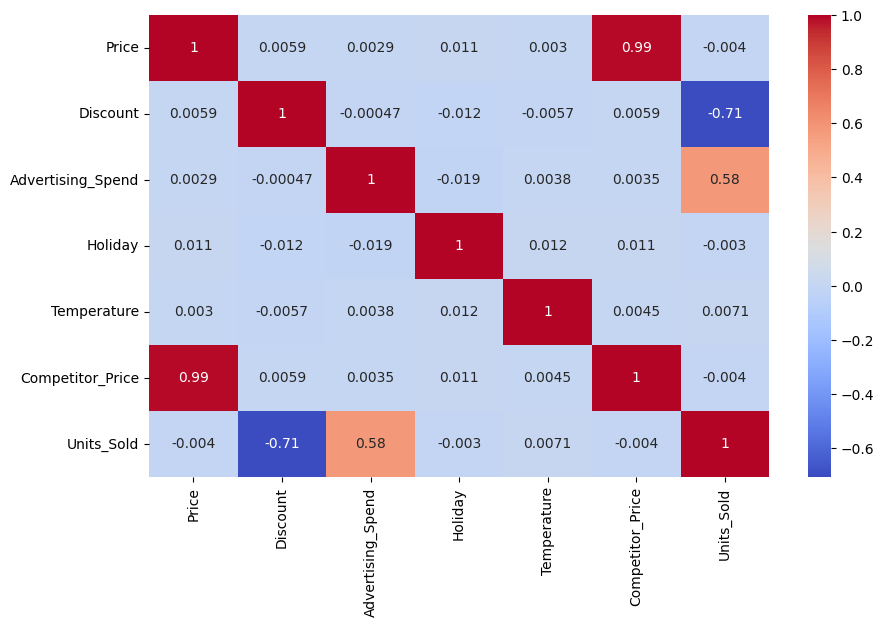

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
## Time Series Analysis

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

In [22]:
df["Revenue"] = (
    df["Price"] *
    df["Units_Sold"] *
    (1 - df["Discount"]/100)
)

In [23]:
## Aggregate daily revenue.

daily = df.groupby("Date")["Revenue"].sum().reset_index()

daily.head()

,Date,Revenue
0,2022-01-01,92229.6125
1,2022-01-02,67303.9990
2,2022-01-03,98408.8620
3,2022-01-04,65329.6435
4,2022-01-05,68891.6360


In [24]:
## Set Date as index.

daily = daily.set_index("Date")

daily.head()

,Revenue
Date,
2022-01-01,92229.6125
2022-01-02,67303.9990
2022-01-03,98408.8620
2022-01-04,65329.6435
2022-01-05,68891.6360


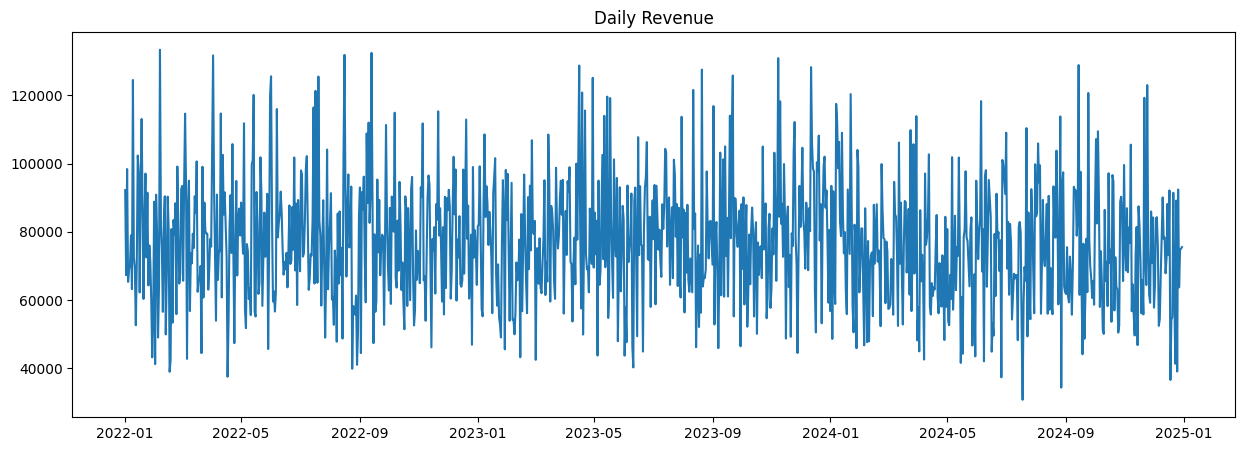

In [25]:
## Plot Daily Revenue.

plt.figure(figsize=(15,5))

plt.plot(daily["Revenue"])

plt.title("Daily Revenue")

plt.show()

In [37]:
## Calculate 7-day Moving Average.

daily["MA7"] = (
    daily["Revenue"]
    .rolling(7)
    .mean()
)

daily["MA7"]

Date
2022-01-01             NaN
2022-01-02             NaN
2022-01-03             NaN
2022-01-04             NaN
2022-01-05             NaN
                  ...     
2024-12-26    67381.759714
2024-12-27    68611.973143
2024-12-28    66227.794000
2024-12-29    67934.333571
2024-12-30    72820.852357
Name: MA7, Length: 1095, dtype: float64

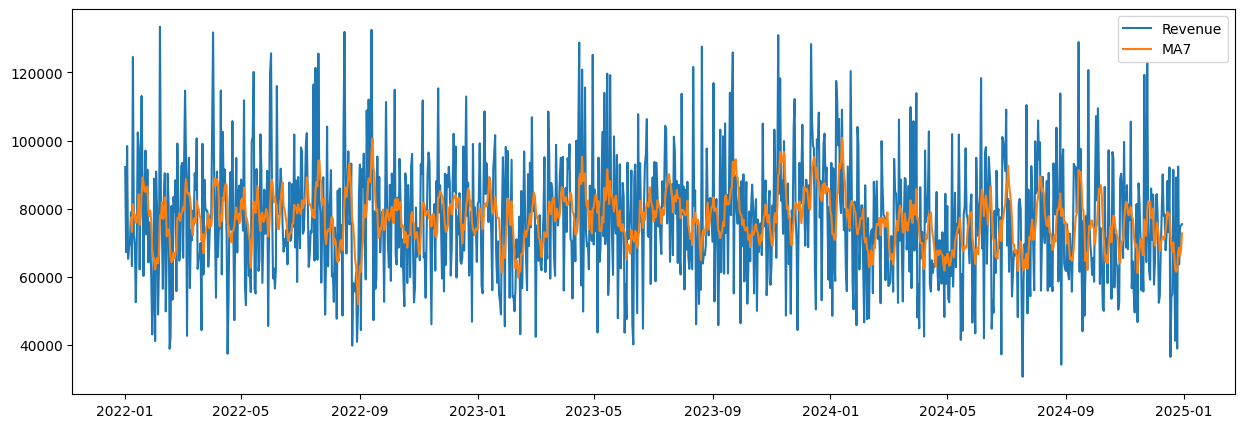

In [27]:
## Plot Moving Average.

plt.figure(figsize=(15,5))

plt.plot(daily["Revenue"], label="Revenue")

plt.plot(daily["MA7"], label="MA7")

plt.legend()

plt.show()

In [35]:
## Calculate 30-day Moving Average.

daily["MA30"] = (
    daily["Revenue"]
    .rolling(30)
    .mean()
)

daily["MA30"]

Date
2022-01-01             NaN
2022-01-02             NaN
2022-01-03             NaN
2022-01-04             NaN
2022-01-05             NaN
                  ...     
2024-12-26    70744.153467
2024-12-27    70894.412633
2024-12-28    70521.052067
2024-12-29    70660.172333
2024-12-30    70370.465533
Name: MA30, Length: 1095, dtype: float64

In [36]:
## Calculate Rolling Standard Deviation.

daily["Rolling_STD"] = (
    daily["Revenue"]
    .rolling(30)
    .std()
)

daily["Rolling_STD"]

Date
2022-01-01             NaN
2022-01-02             NaN
2022-01-03             NaN
2022-01-04             NaN
2022-01-05             NaN
                  ...     
2024-12-26    16537.366876
2024-12-27    16449.182211
2024-12-28    16220.697455
2024-12-29    16242.059317
2024-12-30    16068.479212
Name: Rolling_STD, Length: 1095, dtype: float64

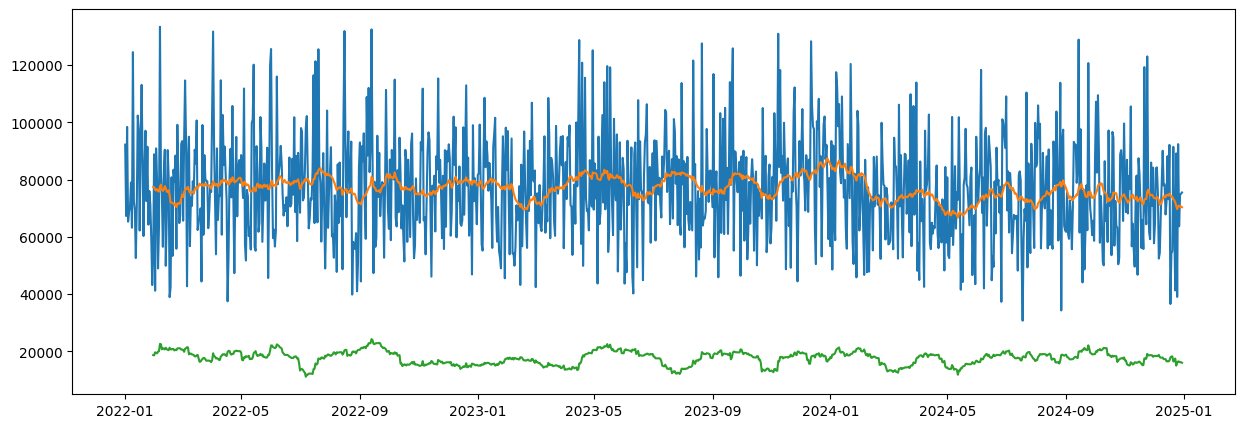

In [34]:
## Plot Rolling Mean and Rolling Std.

plt.figure(figsize=(15,5))

plt.plot(daily["Revenue"])

plt.plot(daily["MA30"])

plt.plot(daily["Rolling_STD"])


plt.show()